# Project 3 - Using Monte Carlo Techniques to Explore Neutron Penetration

### By 11301011

## Abstract

This project used Monte Carlo methods to simulate how neutrons would penetrate layers of different materials. The attenuation length was found for each of water, lead and graphite, resulting in (2.98 $\pm$ 0.03) cm, (10.82 $\pm$ 0.07) and (13.59 $\pm$ 0.08) cm respectively. The probabilities of absorption, transmission and reflection was also computed. Lastly, the Woodcock method was implemented to understand how neutrons would penetrate slabs of different thicknesses. 

The estimated runtime for this document is 70 seconds.

## 0. Initialisation - Libraries and Values

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import curve_fit
from scipy.stats import chi2

In [2]:
# Constants
AVOGADRO = 6.022e23  # Avogadro's number in mol^-1
BARN = 1e-28         # 1 barn = 1e-28 m^2
CM_PER_M = 100       # m to cm 

# Importing values for each material
materials = {
    "Water": {
        "sigma_abs": 0.6652,  # Absorption cross-section (barn)
        "sigma_scat": 103.0,   # Scattering cross-section (barn)
        "density": 1.00,       # g/cm^3
        "molar_mass": 18.0153  # g/mol
    },
    "Lead": {
        "sigma_abs": 0.158,
        "sigma_scat": 11.221,
        "density": 11.35,
        "molar_mass": 207.2
    },
    "Graphite": {
        "sigma_abs": 0.0045,
        "sigma_scat": 4.74,
        "density": 1.67,
        "molar_mass": 12.011
    }
}

## 1. Introduction
To quantify the behaviour of neutrons as it passed through various materials, this project utilises the Monte Carlo random methods. I will first introduce and explore different Monte Carlo methods in general, then apply  it to the context of interactions between neutrons and matter. This will allow a transition into appreciating the theory that governs their interactions, and apply the computational simulation to the neutron penetration. Upon this, an alternative method called the 'Woodcock' method will be compared, summarised in a conclusion that describes the results.


## 2. Exploring Monte Carlo Methods with LCG's and Numpy
A common issue in computational matters is that true randomness is practically impossible to achieve. This requires simulations to utilise 'psuedo-random' numbers, which are unbiased but deterministic. Its deterministic nature is due to the fact that the sequence starts on some number, and the following are generated by the previous ones, resulting in a value that passes randomness tests, but eventually repeats itself. We first introduce Linear Congruential Generators (LCG's), a commonly used type of psuedo number generator. It starts with in initial integer value of $n_0$, known as the 'seed' which allows the iterations using three parameters - the multiplier $a$, increment $c$, and the modulus $m$, based on the equation:

\begin{equation}
  n_{i} = (a n_{i-1} + c) \operatorname{mod} m \,,
\end{equation}

where $mod$ represents the modulo operator. $mod$ means that for $(x)mod(y)$, the remainder of performing \frac{x}{y} will be given [1]. In its current state, integers in the range $[0, m-1]$ will be outputted in a uniformly distributed manner. 

To obtain a uniform distribution in the range $[0,1]$, the outputted number can be divided by $m$. It is preferential to have a large value for $m$ to ensure that it takes a large number of values outputted before the sequence begins repeating after the period $m$. Thus, LCGs use a value of $m$ on the order of $2^{32}$. We can see this demonstrated in a normalised LCG, known as the 'randssp'. 

However, a weakness in the randssp function is that the spectral problem may arise, which is when the outputted values all lie on a hyperplane: a generalisation of the familiar 'plane' into higher dimensions [2]. This is a subtle detail, since it only becomes apparent when the plot is rotated to the angle which reveals this. Hence, this is a cruicial factor to observe when utilising random number generators. To evaluate which random number generator to use, we will explore numpy.random.uniform function and the randssp function. The former originates from the numpy library, where a seed is set for chosen by the library and generates samples from a uniform distribution. The latter is the Multiplicative Congruential Uniform Number Generator from the IBM's Scientific subroutine package, which was used in the 1960's but had a strong correlation between three consecutive values. By seeing these numbers in a 3D plane, we can evaluate which generator is optimal. 

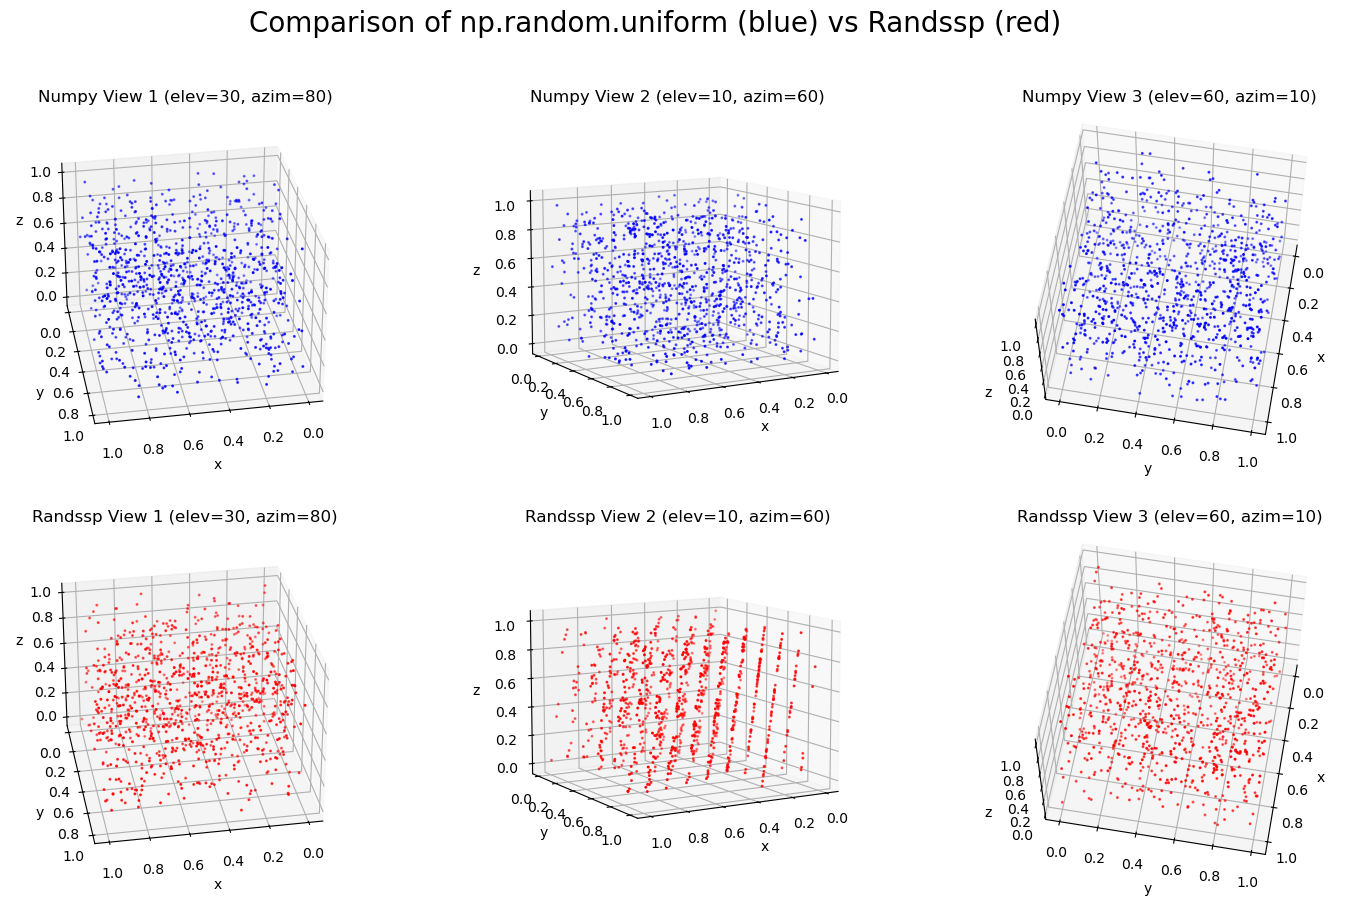

In [3]:
# Determine the number of random values to generate. Save for all 3 dimesnions
sample_size = 1000
x = np.random.uniform(size=sample_size)
y = np.random.uniform(size=sample_size)
z = np.random.uniform(size=sample_size)

# Utilising randssp code to generate random values.
def randssp(p, q):
    m = 2**31
    a = 2**16 + 3
    c = 0
    x = 123456780 # starting seed

    r = np.zeros((p, q))
    for l in range(q):
        for k in range(p):
            x = (a * x + c) % m
            r[k, l] = x / m
    return r

k = randssp(3, sample_size) 


# Test three views, and define the angles. These will be used across both datasets
view_angles = [(30, 80), (10, 60), (60,10)] 

# Plotting
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Comparison of np.random.uniform (blue) vs Randssp (red)", fontsize=20)

# Using axes for numpy's values 
for i in range(3):
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    ax.scatter(x, y, z, c='b', marker='.', s=5)
    ax.set_title(f"Numpy View {i+1} (elev={view_angles[i][0]}, azim={view_angles[i][1]})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.view_init(elev=view_angles[i][0], azim=view_angles[i][1])

# Using axes for randssp's values
for i in range(3):
    ax = fig.add_subplot(2, 3, i + 4, projection='3d')
    ax.scatter(k[0], k[1], k[2], c='r', marker='.', s=5)
    ax.set_title(f"Randssp View {i+1} (elev={view_angles[i][0]}, azim={view_angles[i][1]})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.view_init(elev=view_angles[i][0], azim=view_angles[i][1])

    
plt.show()


From the plots above, it can be seen that numpy's random numbers do not observe the spectral problem, whereas the randssp's view at an elevation of 10 and azimuthal angle of 60 shows all points lying on a plane. This means that the randssp's psuedo-randomness is less valid than that of numpy. 

We can also compare these two (psuedo) random number generators by exploring the convergence of each generator through increasing the number of samples. This wil be done by comparing histograms that are generated from each process. In particular, the mean and the error will be of interest, each denoted by $\mu$ and $\sigma$. The ratio of $\sigma$ to $\mu$ can be indicated to see how far off each are.  

It can be observed that the width of the standard deviation decreases as the sample size is increased, showing a convergence. In order to achieve the true mean when we test for a sample, we hence must appreaciate the Law of Large Numbers: as the sample size increases, the mean approaches the true mean - a seemingly intuitive, but a profound concept [3]. This is illustrated in the figure below too, where as the sample size increases, the error for the mean decreases. 

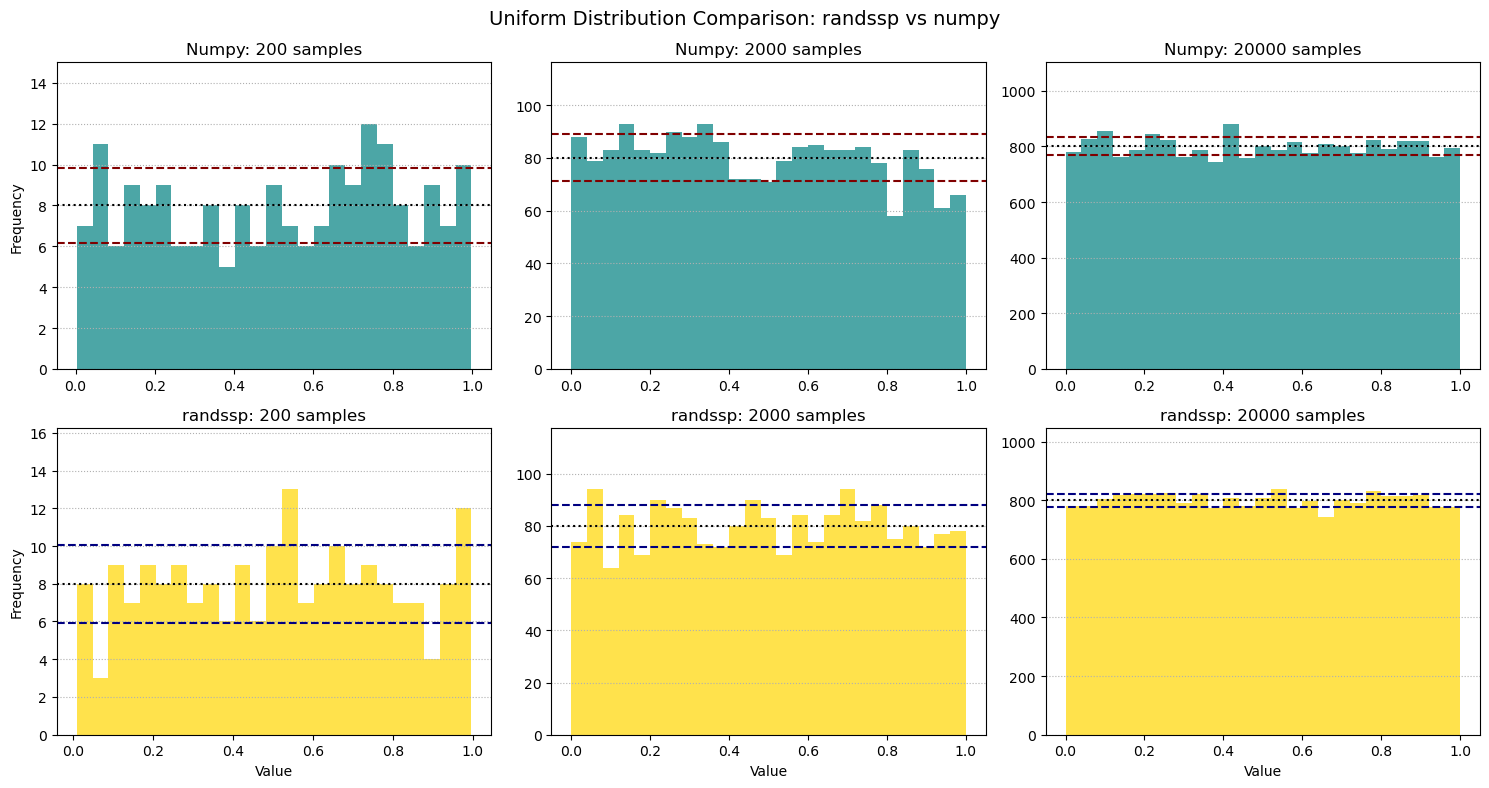

In [4]:
# Sample sizes and bins
sample_sizes = [200, 2000, 20000]  
bin_count = 25 

def analyse_distribution(data, axis, colour):
    """Plots histogram and marks mean \pm standard deviation on the plot"""
    freq, _ = np.histogram(data, bins=bin_count) #create histogram of data inputted
    mu = np.mean(freq) 
    sigma = np.std(freq)
    rel_error = sigma / mu  # Relative error (σ/μ), ie how consistent bin heights are

    # Plot mean and std dev lines
    axis.axhline(mu, color='k', linestyle=':', label=f'μ = {mu:.1f}')
    axis.axhline(mu + sigma, color=colour, linestyle='--', label=f'σ = {rel_error:.2f}μ')
    axis.axhline(mu - sigma, color=colour, linestyle='--')

    # Auto-adjust y-axis
    max_freq = max(freq)
    axis.set_ylim(top=max_freq * 1.25) 

    return mu, sigma

# Set up figure w 2 rows 3 columns
fig, axs = plt.subplots(2, len(sample_sizes), figsize=(15, 8), tight_layout=True)
fig.suptitle('Uniform Distribution Comparison: randssp vs numpy', fontsize=14)

# Compare randssp and numpy for each sample size
for idx, size in enumerate(sample_sizes):
    # Numpy's uniform distribution (top row)
    np_data = np.random.uniform(0, 1, size)
    axs[0, idx].hist(np_data, bins=bin_count, color='teal', alpha=0.7)
    analyse_distribution(np_data, axs[0, idx], 'maroon')
    axs[0, idx].set_title(f'Numpy: {size} samples')
    axs[0, idx].grid(axis='y', linestyle=':') #only interested in horizontal 

    # randssp distribution (bottom row)
    custom_data = randssp(size, 1).flatten()  # Flatten for consistency
    axs[1, idx].hist(custom_data, bins=bin_count, color='gold', alpha=0.7)
    analyse_distribution(custom_data, axs[1, idx], 'navy')
    axs[1, idx].set_title(f'randssp: {size} samples')
    axs[1, idx].grid(axis='y', linestyle=':')

# Axis labels
for ax in axs[1, :]:
    ax.set_xlabel("Value")
for ax in axs[:, 0]:
    ax.set_ylabel("Frequency")

plt.show()

These plots demonstrate that as the sample size is increased, the error converges and decreases. While it portrays the validity of both of the random number methods, the spectral problem from the randssp makes numpy's random number generation less biased. Hence, from this point onwards, we will be using the numpy random number generation. 

## 3. Exponential Distribution and the Mean Free Path of the Neutron
For this project, we will explore the mean free path that the neutron will take before interacting with matter. For this, radnom numbers wil be generated based on a probability distribution given by 

$$ P(x) = \frac{1}{\lambda}e^{\frac{-x}{\lambda}} $$

here, $x$ is the distance travelled by the neutron, and $\lambda$ is the mean free path. Integrating the probability distribution function yields the CDF: $1 - e^{\frac{-x}{\lambda}}$. To generate values from this distribution, we will use the inverse transform sampling method, where we start with a random number $n$ from numpy, and equate it to the inverted equation [4]. Following this, we solve for $x$:

$$ n = 1 - e^{\frac{-x}{\lambda}} \Rightarrow x = - \lambda \ln(1 - n). $$

Since the distribution is normalised, the equation can be further simplified to 

$$ x = - \lambda \ln(n). $$


This can be related to the number of molecules, N, absorbed is calculated by using
$$ N = \frac{\rho N_A}{M} $$

in which $\rho$ is the density of the material, $N_A$ is Avogadro's number, and M is the molar mass [5]. This can be then used to define the macroscopic cross section $\Sigma$ by calculating

$$ \Sigma = N \sigma $$

where $\sigma$ is the microscopic cross section. This finally relates back to $\lambda$ by 

$$ \lambda = \frac{1}{\Sigma}.$$

### 3.1 Preparing Materials and an Exponential Distribution
During the initialisation, the values were imported into the code. Now, we will perform calculations to obtain the calculated quantities that will be used for the simulation. 

In [5]:
# Calculates properties for materials 
for name, props in materials.items():
    
    # Convert to SI units
    sigma_abs = props["sigma_abs"] * BARN #1 barn is 1e-28 m^2
    sigma_scat = props["sigma_scat"] * BARN
    sigma_total = sigma_abs + sigma_scat
    density = props["density"] * 1000  # g/cm^3 to kg/m^3
    molar_mass = props["molar_mass"] / 1000  # g/mol to kg/mol
    
    n_density = (density*AVOGADRO) / molar_mass
    
    # Macroscopic cross-sections
    macro_abs = n_density*sigma_abs
    macro_scat = n_density*sigma_scat
    macro_total = macro_abs + macro_scat
    
    # Mean free path (mfp) in metres
    mfp = 1 / macro_total
    
    # Scattering probability
    p_scat = macro_scat / macro_total
    
    # Store calculated properties, dictionary
    props.update({
        "macro_abs": macro_abs,
        "macro_scat": macro_scat,
        "macro_total": macro_total,
        "mfp": mfp,
        "p_scat": p_scat
    })

# Print material properties table for ease in reading
print(f"{'Material':<10} | {'MFP (cm)':>12} | {'Abs XS (1/m)':>12} | {'Scat XS (1/m)':>12} | {'Total XS (1/m)':>15} | {'P_scat':>10}")
print("-"*90)
for name, props in materials.items():
    print(f"{name:<10} | {props['mfp']*CM_PER_M:12.4f} | {props['macro_abs']:12.3e} | {props['macro_scat']:12.3e} | {props['macro_total']:15.3e} | {props['p_scat']:10.4f}")


Material   |     MFP (cm) | Abs XS (1/m) | Scat XS (1/m) |  Total XS (1/m) |     P_scat
------------------------------------------------------------------------------------------
Water      |       0.2886 |    2.224e+00 |    3.443e+02 |       3.465e+02 |     0.9936
Lead       |       2.6641 |    5.212e-01 |    3.702e+01 |       3.754e+01 |     0.9861
Graphite   |       2.5173 |    3.768e-02 |    3.969e+01 |       3.973e+01 |     0.9991


Hence, we will use the material properties as listed to compute $\lambda$, then utilise the random number generation to relate it to the distance travelled by the neutrons. We will first obtain random numbers in an exponential distribution using the function below. For consistency, 5000 numbers will be generated, displaying their frequency in a histogram. 

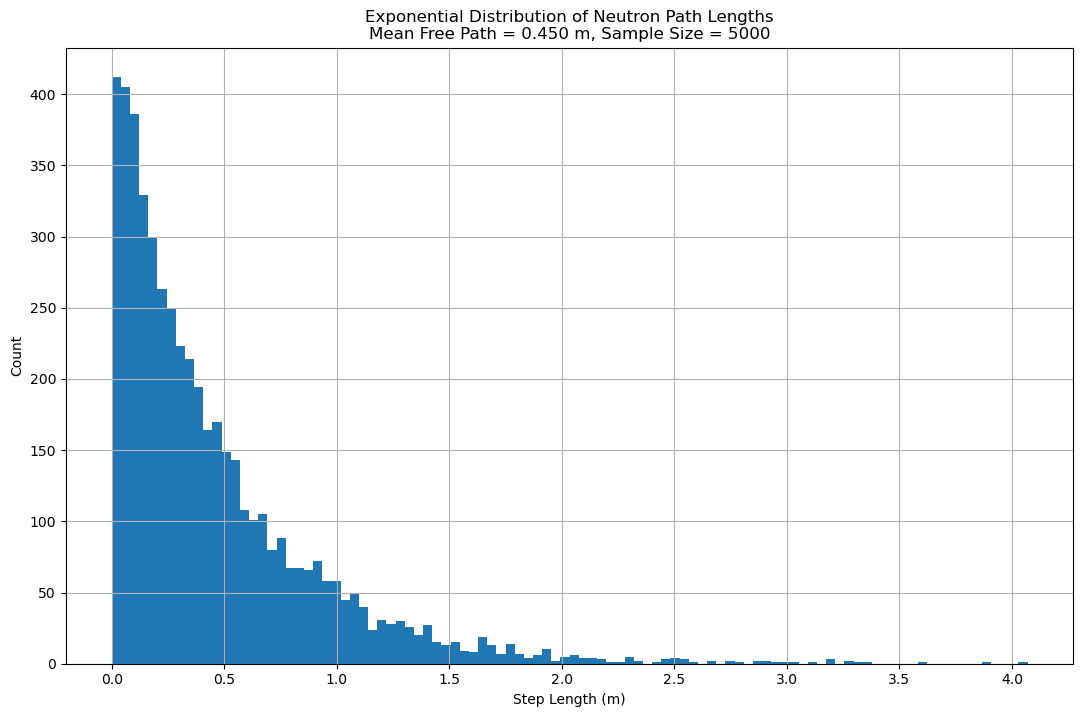

In [6]:
def inverse_cdf_sampling(sample_size, density, molar_mass, micro_cross_section):
    """ Applies inverse transform sampling to generate random distances based on exponential distribution """
    # Number density calculation
    n_density = (density * AVOGADRO) / molar_mass
    
    # Macroscopic cross-section
    macro_xs = n_density * micro_cross_section
    
    # Mean free path
    mfp = 1 / macro_xs
    
    # Generate exponential random distances
    random_nums = np.random.uniform(0, 1, sample_size)
    distances = -mfp * np.log(random_nums)
    
    return distances, mfp

# Generate and plot data for water
sample_size = 5000
distances, mfp_water = inverse_cdf_sampling(
    sample_size=sample_size,
    density=materials["Water"]["density"]*1000,  # Convert g/cm³ to kg/m³
    molar_mass=materials["Water"]["molar_mass"]/1000,  # Convert g/mol to kg/mol
    micro_cross_section=materials["Water"]["sigma_abs"]*BARN
)

# Plot histogram
plt.figure(figsize=(13, 8))
plt.hist(distances, bins=100)
plt.xlabel('Step Length (m)')
plt.ylabel('Count')
plt.title(f'Exponential Distribution of Neutron Path Lengths\n'
         f'Mean Free Path = {mfp_water:.3f} m, Sample Size = {sample_size}')
plt.grid(True)
plt.show()

We can then take the logarithm of N_R and plot against R_i to obtain the attenuation length. This can be obtained by iterating through the data in the exponential function, count the mean

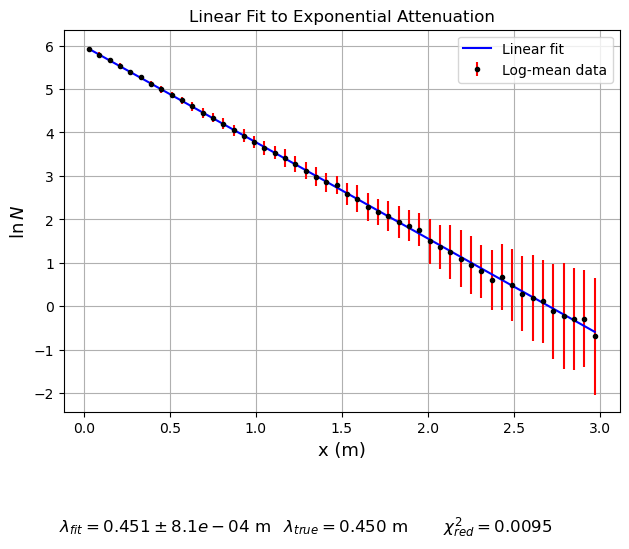

In [7]:
# Redefine values 
lambda_true = 0.450                  
n_particles = 3000
n_bins = 50
n_repeats = 100
x_max = 3.0                          
bin_width = x_max / n_bins

# Defining three functions to sample, then form a linear plot, then evaluate
def sample_exponential_distances(lambda_val, n):
    """Samples neutron travel distances before interaction with inverse CDF"""
    u = np.random.uniform(size=n)
    return -lambda_val * np.log(u)

def linear_model(x, slope, intercept):
    """Preparing linear model to use in fitting"""
    return slope * x + intercept

def reduced_chi2(observed, uncertainty, model, dof=None):
    """ Reduced chi square calculator, uses dof to reduce it """
    chi2 = np.sum(((observed - model) / uncertainty) ** 2)
    return chi2 / (dof if dof else len(observed) - 2)


binned_counts = np.zeros((n_repeats, n_bins)) #returns a fresh array with 0's

# Binning results
for i in range(n_repeats):
    distances = sample_exponential_distances(lambda_true, n_particles)
    distances = distances[distances < x_max]
    counts, bin_edges = np.histogram(distances, bins=n_bins, range=(0, x_max))
    binned_counts[i] = counts

# Computing mean, stdev for the bins
mean_counts = np.mean(binned_counts, axis=0)
std_counts = np.std(binned_counts, axis=0)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Cleaning data to remove invalid bins
valid_bins = (mean_counts > 0) & (std_counts > 0) #boolean masking to easily remove invalid data
x_vals = bin_centers[valid_bins]
ln_counts = np.log(mean_counts[valid_bins])
ln_errors = std_counts[valid_bins] / mean_counts[valid_bins]

# Taking logarithm to apply a linear model, then taking chi squared
(fit_slope, fit_intercept), cov = np.polyfit(x_vals, ln_counts, deg=1, w=1/ln_errors, cov=True)
lambda_fit = -1 / fit_slope
lambda_fit_err = np.sqrt(cov[0, 0]) / fit_slope**2

fitted_ln_model = linear_model(x_vals, fit_slope, fit_intercept)
chi2_red = reduced_chi2(ln_counts, ln_errors, fitted_ln_model)

# Plotting
fig, ax = plt.subplots()

ax.errorbar(x_vals, ln_counts, yerr=ln_errors, fmt='k.', ecolor='red', label='Log-mean data')
ax.plot(x_vals, fitted_ln_model, 'b-', label='Linear fit')
ax.set_xlabel('x (m)', fontsize=13)
ax.set_ylabel(r'$\ln N$', fontsize=13)
ax.set_title('Linear Fit to Exponential Attenuation')
ax.legend()
ax.grid(True)

# Summary text
fig.text(0.10, -0.12, rf'$\lambda_{{fit}} = {lambda_fit:.3f} \pm {lambda_fit_err:.1e}$ m', fontsize=12)
fig.text(0.45, -0.12, rf'$\lambda_{{true}} = {lambda_true:.3f}$ m', fontsize=12)
fig.text(0.70, -0.12, rf'$\chi^2_{{red}} = {chi2_red:.4f}$', fontsize=12)

plt.tight_layout()
plt.show()


From here, the linear trend can confirm the exponential attenuation. $\lambda$ is shown to be indeed 0.45m. The error bar is represented through the standard deviation across the simulations, utilising the fact that the errors originate from poisson counting statistics. While traditionally, the reduced chi-square value is considered an overfit below 0.5, the large sample size allows the justification that this is in fact an acceptable fit. 

### 3.2 Using Vectors
Now that the exponential distribution has been set, we must also use vectors as neutrons follow a direction. We can do this by generating random values for $\phi$ and $\theta$ in spherical polar coordinates:

$$x=\sin{\theta}\cos{\phi} $$
$$y = \sin{\theta}\sin{\phi}$$
$$z = \cos{\theta} $$

We must prevent the bias that can cause points to accumulate at the poles. This occurs because the area element on a sphere in spherical coordinates is 
$$ dA = \sin \theta d \theta d \phi $$

shich means that intervals equal in $\theta$ do not sweep out equal areas, and so the regions near $\theta = 0$ and $\theta = \pi$ cover smaller areas than that near the equator. Hence, we can sample $cos\theta$ uniformly instead by using the random number $n$ to generate 

$$ \theta = \arccos(1-2n) $$

to spread the points in an unbiased manner across the sphere. 

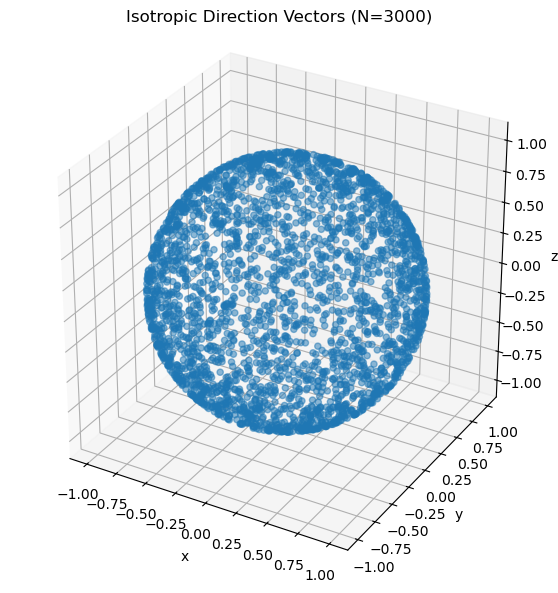

In [8]:
def generate_isotropic_direction():
    """
    Generates a random unit vector with isotropic distribution.
    Uniform distribution across 4pi steradians.
    """
    # Random angles (theta between 0 and pi, phi between 0 and 2pi)
    theta = np.arccos(1 - 2*np.random.uniform()) #correction
    phi = 2*np.pi*np.random.uniform()
    
    # Convert to Cartesian coordinates
    x = np.sin(theta)*np.cos(phi)
    y = np.sin(theta)*np.sin(phi)
    z = np.cos(theta)
    
    return x, y, z

def generate_isotropic_vectors(num_vectors):
    """ 
    Generates an array of isotropic unit vectors
    For the direction of the neutrons. 
    """
    vectors = np.array([generate_isotropic_direction() for _ in range(num_vectors)])
    return vectors.T  # Transpose to get (3, N) shape

# Generate and plot vectors
num_vectors = 3000
vectors = generate_isotropic_vectors(num_vectors)

# Plotting
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(vectors[0], vectors[1], vectors[2], alpha=0.5)
ax.set_box_aspect((1, 1, 1))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.title(f"Isotropic Direction Vectors (N={num_vectors})")
plt.show()

### 3.3 Combining Exponential Function and Vectors
We can now combine the exponential function data to the sphere to turn them into vectors.

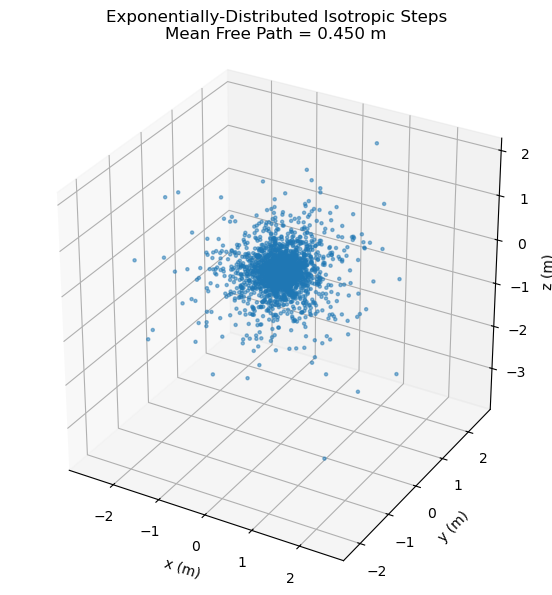

In [9]:
def generate_exponential_isotropic_vectors(sample_size, material):
    """ 
    Combines the concept of the two previous functions to 
    generate vectors exponentially distributed in length and 
    isotropic in direction.
    """
    
    # Recall material properties
    density = material["density"] * 1000  # g/cm^3 to kg/m^3
    molar_mass = material["molar_mass"] / 1000  # g/mol to kg/mol
    micro_xs = material["sigma_abs"] * BARN
    
    # Generate distances
    distances, mfp = inverse_cdf_sampling(
        sample_size=sample_size,
        density=density,
        molar_mass=molar_mass,
        micro_cross_section=micro_xs
    )
    
    # Generate isotropic directions
    directions = generate_isotropic_vectors(sample_size)
    
    # Combine into 3D vectors
    x = distances * directions[0]
    y = distances * directions[1]
    z = distances * directions[2]
    
    return x, y, z, mfp

# Generate and plot for Water
sample_size = 3000
x_exp, y_exp, z_exp, mfp_water = generate_exponential_isotropic_vectors(
    sample_size=sample_size,
    material=materials["Water"]
)

# Plotting
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_exp, y_exp, z_exp, alpha=0.5, s=5)
ax.set_box_aspect((1, 1, 1))
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title(f"Exponentially-Distributed Isotropic Steps\nMean Free Path = {mfp_water:.3f} m")
plt.tight_layout()
plt.show()

## 4. Simulating Neutron Penetration Through Various Materials

To begin the simulation, we first begin by tracking one neutron as it penetrates through the materials. The neutron is launched initially from the origin, then we use the sample from the previous exponential distribution to generate the step length. Following this, the interaction probabilites are brought in from the previous steps, determining whether the neutron is absorbed or not. Since these are binary outcomes (absorbed or scattered), and have a set probability across each trial, it allows the determination of the neutron's outcome. Furthermore, since the next step of the neutron only depends on the current state, this follows a Markov Chain Monte Carlo method [6]. The direction of the scattered neutron is modelled randomly through the previous isotropic scattering, allowing a uniform sample over 4 $\pi$ steradians. 

Computationally, we can update the position of the neutron after it scatters before we compare to the boundary condition. In the case that the position exceeds the 10cm slab, then we can observe transmission. If not, it is considered to be reflected. Three trials of the simulation are run for each material, and the path taken is visualised after the simulation. This process is called the random walk, and the simulation will be run until each interaction type is observed for al the materials. The neutron's positional history will be plotted in 3D. 

### 4.1 Passing One Neutron
We will begin by simulating one neutron passing through each material.

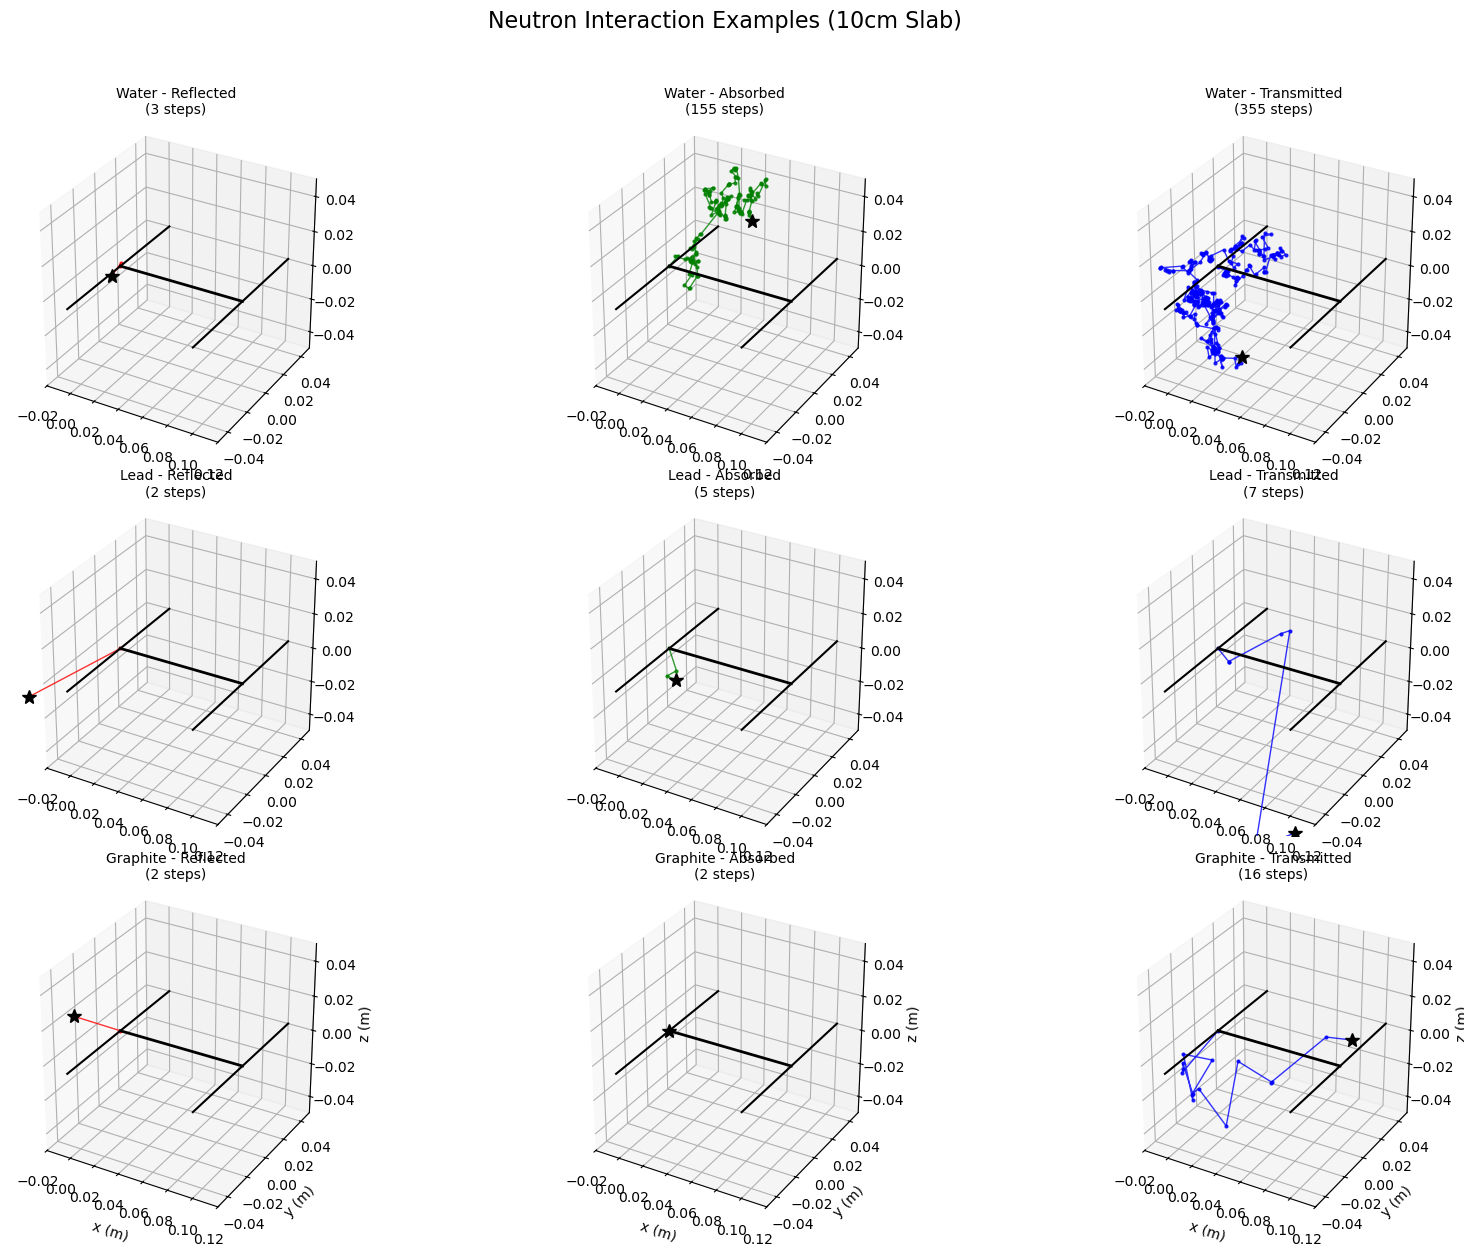

In [10]:
def simulate_neutron(material, thickness, max_steps=1000, visualise=False):
    """
    Simulate a single neutron's path through a material using material property dictionary,
    slab thickness, steps and visualisation. 
    Path is a numpy array of positions.
    Returns only when neutron is absorbed, reflected, or transmitted.
    """
    # Load material properties 
    mean_free_path = material['mfp']
    macro_abs = material['macro_abs']
    macro_total = material['macro_total']
    
    # Initialise tracking
    position = np.array([0.0, 0.0, 0.0])  # Start at origin (left)
    path = [position.copy()]  # Store trajectory
    absorbed = reflected = transmitted = False
    
    # Simulation loop
    for _ in range(max_steps):
        # Generate step length using exponential distribution
        step_length = -mean_free_path * np.log(np.random.uniform())
        
        # Determine interaction type 
        if np.random.uniform() < macro_abs / macro_total:
            absorbed = True
            # Move slightly into the material before absorption
            direction = np.array([1, 0, 0])  # Default forward direction
            new_position = position + 0.001 * thickness * direction
            path.append(new_position.copy())
            break
            
        # Isotropic scattering direction
        theta = np.arccos(1 - 2*np.random.uniform())  # Polar angle
        phi = 2*np.pi*np.random.uniform()  # Azimuthal angle
        direction = np.array([
            np.sin(theta)*np.cos(phi),
            np.sin(theta)*np.sin(phi),
            np.cos(theta)
        ])
        
        # Update position
        new_position = position + step_length * direction
        new_x = new_position[0]
        
        # Check boundary conditions
        if new_x < 0:
            reflected = True
            # Ensure we cross the boundary for visualisation
            path.append(new_position.copy())
            break
        elif new_x > thickness:
            transmitted = True
            path.append(new_position.copy())
            break
        else:
            position = new_position
            path.append(position.copy())
    
    # Convert path to numpy array
    path_array = np.array(path)
    
    # Visualisation
    if visualise:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot the path with color coding
        if absorbed:
            color = 'green'
        elif reflected:
            color = 'red'
        else:
            color = 'blue'
            
        ax.plot(path_array[:,0], path_array[:,1], path_array[:,2], 
                f'{color}-o', markersize=3, linewidth=1)
        
        # Plot slab boundaries
        ax.plot([0, thickness], [0, 0], [0, 0], 'k--', linewidth=2)
        ax.plot([0, 0], [-thickness/2, thickness/2], [0, 0], 'k-', linewidth=1)
        ax.plot([thickness, thickness], [-thickness/2, thickness/2], [0, 0], 'k-', linewidth=1)
        
        # Set ratio of boxes
        ax.set_box_aspect([1, 1, 1])
        
        ax.set_xlabel('x (m)')
        ax.set_ylabel('y (m)')
        ax.set_zlabel('z (m)')
        ax.set_title(f"Neutron Path (Thickness: {thickness}m)")
        plt.show()
    
    return absorbed, reflected, transmitted, path_array


def simulate_and_save_examples(materials, thickness=0.1, max_steps=1000):
    """
    Simulates and saves 9 representative neutron interactions:
    1 reflection, 1 absorption, 1 transmission for each material.
    Only saves paths that properly start at x=0 and end beyond boundaries.
    """
    saved_interactions = {
        'Water': {'reflected': None, 'absorbed': None, 'transmitted': None},
        'Lead': {'reflected': None, 'absorbed': None, 'transmitted': None},
        'Graphite': {'reflected': None, 'absorbed': None, 'transmitted': None}
    }  # starting empty
    
    for mat_name, mat_props in materials.items():
        # Continue until all three outcomes are captured
        while None in saved_interactions[mat_name].values():
            absorbed, reflected, transmitted, path = simulate_neutron(mat_props, thickness, max_steps)
            
            # Verify path starts at x=0 and properly ends beyond boundaries
            if not np.isclose(path[0,0], 0):
                continue  # Skip if doesn't start at boundary
                
            if reflected and not path[-1,0] < 0:
                continue  # Skip if not properly reflected
                
            if transmitted and not path[-1,0] > thickness:
                continue  # Skip if not properly transmitted
                
            # Save first valid occurrence of each outcome type
            if reflected and saved_interactions[mat_name]['reflected'] is None:
                saved_interactions[mat_name]['reflected'] = {
                    'path': path,
                    'final_position': path[-1],
                    'steps': len(path)
                }
            elif absorbed and saved_interactions[mat_name]['absorbed'] is None:
                # For absorption, ensure it happened inside the slab
                if 0 <= path[-1,0] <= thickness:
                    saved_interactions[mat_name]['absorbed'] = {
                        'path': path,
                        'final_position': path[-1],
                        'steps': len(path)
                    }
            elif transmitted and saved_interactions[mat_name]['transmitted'] is None:
                saved_interactions[mat_name]['transmitted'] = {
                    'path': path,
                    'final_position': path[-1],
                    'steps': len(path)
                }
    
    return saved_interactions


def visualise_saved_interactions(saved_data, thickness=0.1):
    """
    Creates a 3×3 visualisation grid of saved interactions with boundaries shown
    """
    fig = plt.figure(figsize=(18, 12))
    plt.suptitle("Neutron Interaction Examples (10cm Slab)", y=1.02, fontsize=16)
    
    materials = list(saved_data.keys())
    outcomes = ['reflected', 'absorbed', 'transmitted']
    
    for i, mat_name in enumerate(materials):
        for j, outcome in enumerate(outcomes):
            ax = fig.add_subplot(3, 3, i*3 + j + 1, projection='3d')
            data = saved_data[mat_name][outcome]
            path = data['path']
            
            # Colour coding by outcome type
            colour = {'reflected': 'red', 'absorbed': 'green', 'transmitted': 'blue'}[outcome]
            ax.plot(path[:,0], path[:,1], path[:,2], 
                    f'{colour[0]}-o', markersize=2, linewidth=1, alpha=0.8)
            
            # Mark final position with a star
            ax.plot([path[-1,0]], [path[-1,1]], [path[-1,2]], 
                    'k*', markersize=10)
            
            # Slab boundaries (thicker lines)
            ax.plot([0, thickness], [0, 0], [0, 0], 'k-', linewidth=2)
            ax.plot([0, 0], [-thickness/2, thickness/2], [0, 0], 'k-', linewidth=1.5)
            ax.plot([thickness, thickness], [-thickness/2, thickness/2], [0, 0], 'k-', linewidth=1.5)
            
            # Annotations
            ax.set_title(f"{mat_name} - {outcome.capitalize()}\n({data['steps']} steps)", fontsize=10)
            
            # Set consistent viewing ranges
            ax.set_xlim(-0.02, thickness+0.02)
            ax.set_ylim(-thickness/2, thickness/2)
            ax.set_zlim(-thickness/2, thickness/2)
            ax.set_box_aspect((1,1,1))
            
            # Axis labels only on bottom row
            if i == 2:
                ax.set_xlabel('x (m)')
                ax.set_ylabel('y (m)')
                ax.set_zlabel('z (m)')
    
    plt.tight_layout()
    plt.show()
    return fig


# Execute the simulation and visualisation
saved_interactions = simulate_and_save_examples(materials)
fig = visualise_saved_interactions(saved_interactions)

The above interactions ensure that the neutron starts at (0,0,0), then interacts with the material. Each material has one of each interaction shown above, with the star denoting the end point of the interaction. Bars have been added (in an H shape) to show the perspective of the boundaries.

### 4.2 Passing a Flux of Neutrons
Now the model can be upgraded to simulate a large number of neutrons. This is done by implementing 5000 neutrons to be sent into the system to evaluate the absorption, transmission and reflection probabilities. Several repeats will be performed to ensure that it minimises random errors, although this implies a longer time to run the code. Thus, only the x coordinates will be tracked throughout this simulation. This is performed for water, lead and graphite slabs as before, each with a thickness of 10cm. 

These functions will be split into three cells. First, the flux of neutrons will be simulated and repeated. Then, a separate function will calculate the attenuation coefficient by utilising binomial statistics and performing a weighted fit. This will derive the attenuation rates, and from here the data will be displayed in a pie chart. 

In [11]:
def simulate_neutron_flux(material, thickness=0.1, n_neutrons=5000, n_repeats=10):
    """
    Simulates a flux of neutrons (5000) passing through the materials
    Over 10 repeats
    Calculates the rates, with uncertainties
    """
    results = {'absorption': [], 'reflection': [], 'transmission': []}
    
    for _ in range(n_repeats):
        absorbed = reflected = transmitted = 0
        
        for _ in range(n_neutrons):
            # Simplified simulation tracking only x-coordinate
            x_pos = 0.0
            while True:
                step_length = -material['mfp'] * np.log(np.random.uniform())
                
                if np.random.uniform() < material['macro_abs']/material['macro_total']:
                    absorbed += 1
                    break
                    
                new_x = x_pos + step_length * (2*np.random.uniform()-1)  # Simplified isotropic scattering in 1D
                
                if new_x < 0:
                    reflected += 1
                    break
                elif new_x > thickness:
                    transmitted += 1
                    break
                else:
                    x_pos = new_x
        
        # Store rates for this repeat
        total = absorbed + reflected + transmitted
        results['absorption'].append(absorbed/total)
        results['reflection'].append(reflected/total)
        results['transmission'].append(transmitted/total)
    
    # Calculate mean and standard error
    stats = {}
    for key in results:
        stats[key] = {
            'mean': np.mean(results[key]),
            'error': np.std(results[key])/np.sqrt(n_repeats)
        }
    
    return stats

In [12]:
def calculate_attenuation(material, thickness_values, n_neutrons=3000, n_repeats=5):
    """
    Calculate attenuation coefficients. 
    """
    results = {
        'thicknesses': np.array(thickness_values),
        'alpha': np.zeros(len(thickness_values)),
        'alpha_error': np.zeros(len(thickness_values))
    }
    
    for i, t in enumerate(thickness_values):
        transmissions = []
        for _ in range(n_repeats):
            transmitted = 0
            for _ in range(n_neutrons):
                x_pos = 0.0
                while True:
                    # Exponential step length
                    step_length = -material['mfp'] * np.log(np.random.uniform())
                    
                    # Absorption check
                    if np.random.uniform() < material['macro_abs']/material['macro_total']:
                        break
                        
                    # Isotropic scattering in 1D
                    new_x = x_pos + step_length * np.sign(np.random.uniform() - 0.5)
                    
                    # Boundary checks
                    if new_x > t:
                        transmitted += 1
                        break
                    elif new_x < 0:
                        break  # Reflected
                    else:
                        x_pos = new_x
            
            transmissions.append(transmitted/n_neutrons)
        
        # Binomial statistics
        p = np.mean(transmissions)
        results['alpha'][i] = p
        results['alpha_error'][i] = np.sqrt(p*(1-p)/n_neutrons)  # Binomial standard error
    
    # Filter and fit
    mask = results['alpha'] > 0  # Only points with transmission
    if np.sum(mask) < 2:
        raise ValueError("Need at least 2 points with transmission > 0")
    
    x = results['thicknesses'][mask]
    y = np.log(results['alpha'][mask])
    y_err = results['alpha_error'][mask]/results['alpha'][mask]  # Error on ln(alpha)
    
    # Weighted fit
    (slope, intercept), cov = np.polyfit(x, y, 1, w=1/y_err, cov=True)
    results['tau'] = -1/slope
    results['tau_error'] = np.sqrt(cov[0,0])/slope**2
    
    return results

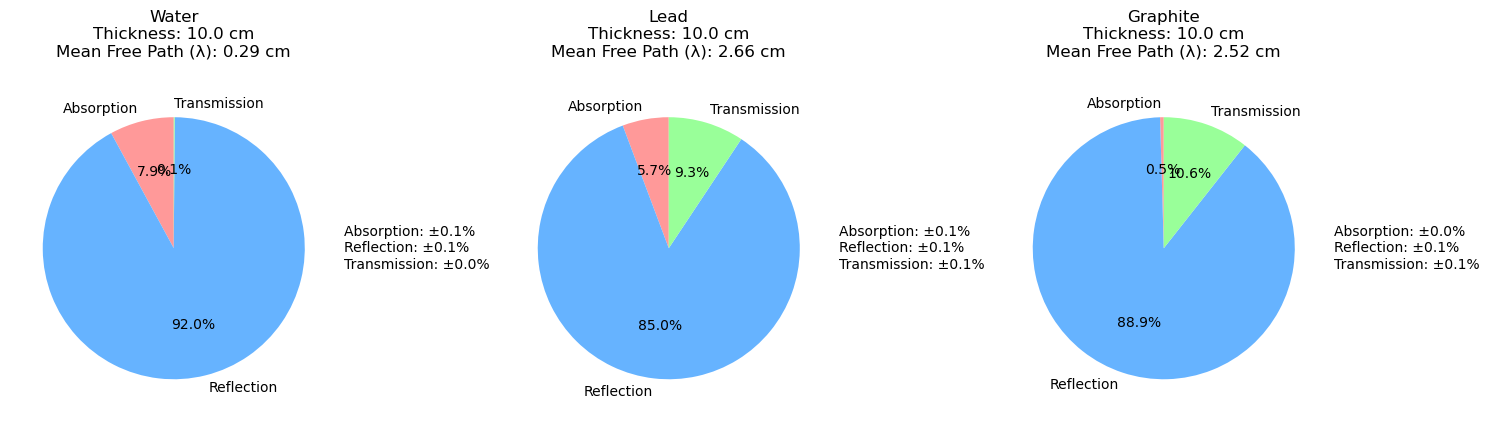

In [13]:
def plot_material_properties(materials, thickness=0.1, n_neutrons=10000, n_repeats=10):
    """
    Plots pie charts for reflection, absorption, and transmission for each material
    Display the mean free path (lambda) 
    """
    n_materials = len(materials)
    fig, axes = plt.subplots(1, n_materials, figsize=(5*n_materials, 5))
    
    if n_materials == 1:
        axes = [axes]  # Make it iterable for single material case
    
    for (mat_name, material), ax in zip(materials.items(), axes):
        stats = simulate_neutron_flux(material, thickness, n_neutrons, n_repeats)
        
        labels = ['Absorption', 'Reflection', 'Transmission']
        sizes = [stats['absorption']['mean'], stats['reflection']['mean'], stats['transmission']['mean']]
        errors = [stats['absorption']['error'], stats['reflection']['error'], stats['transmission']['error']]
        
        # Create pie chart
        wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%',
                                          startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
        
        # Add title with material name and lambda value
        title = (f"{mat_name}\n"
                 f"Thickness: {thickness*100:.1f} cm\n"
                 f"Mean Free Path (λ): {material['mfp']*100:.2f} cm")
        ax.set_title(title, pad=20)
        
        # Add error information
        error_text = "\n".join([f"{label}: ±{error*100:.1f}%" 
                              for label, error in zip(labels, errors)])
        ax.text(1.3, 0, error_text, ha='left', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()


plot_material_properties(materials)

This visualisation shows the reflection, absorption and transmission probabilities for the 10cm thickness of the three materials. By confirming that all the neutrons were indeed coming out of the simulation, we confirmed the accuracy of the simulation. Each mean free path is also denoted above the pie chart.

Next, the attenuation length for each material was simulated. The value of interest was the fraction $\alpha$ of the neutrons that managed to penetrate through a certain thickness of water, lead or graphite, accepting all forms as outcomes for the interaction. The relationship follows as

$$ \alpha = e^{-x/\tau} $$

were x is the thickness and $\tau$ is the function of $\lambda$. By evaluating the value of $\tau$ for the range of thicknesses, we can linearlise the equation by taking the logarithm and finding the value of $\tau$ through the gradient. For this, a function will calculate the attenuation, then plot it to visually observe the exponentially decaying nature. Once this is confirmed, the logarithm will be taken.

### 4.3 Calculating the Attenuation

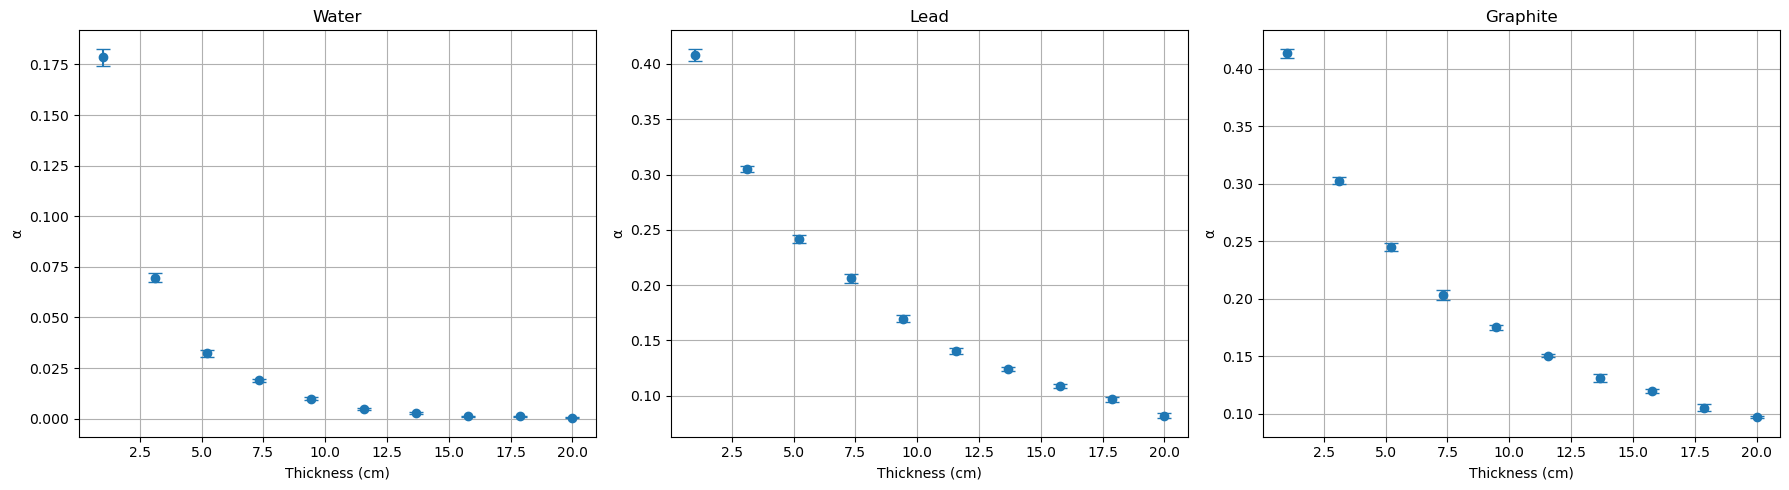

In [14]:
def calculate_attenuation(material, thickness_values, n_neutrons=3000, n_repeats=5):
    """
    Calculates the attenuation for different thicknesses.
    """
    results = {
        'thicknesses': np.array(thickness_values),
        'alpha': np.zeros(len(thickness_values)),
        'alpha_error': np.zeros(len(thickness_values))
    }
    
    for i, t in enumerate(thickness_values):
        transmissions = []
        for _ in range(n_repeats):
            transmitted = 0
            for _ in range(n_neutrons):
                x_pos = 0.0
                while True:
                    # Exponential step length
                    step_length = -material['mfp'] * np.log(np.random.uniform())
                    
                    # Absorption check
                    if np.random.uniform() < material['macro_abs']/material['macro_total']:
                        break
                        
                    # Isotropic scattering in 1D
                    new_x = x_pos + step_length * np.sign(np.random.uniform() - 0.5)
                    
                    # Boundary checks
                    if new_x > t:
                        transmitted += 1
                        break
                    elif new_x < 0:
                        break  # Reflected
                    else:
                        x_pos = new_x
            
            transmissions.append(transmitted/n_neutrons)
        
        # Calculate mean and standard error
        results['alpha'][i] = np.mean(transmissions)
        results['alpha_error'][i] = np.std(transmissions)/np.sqrt(n_repeats)
    
    return results

def plot_attenuation_vs_thickness(materials, thickness_values, n_neutrons=3000, n_repeats=5):
    """
    Plots attenuation (transmission fraction) vs thickness for multiple materials
    
    Args:
        materials: Dictionary of material properties
        thickness_values: Array of thicknesses to test (in meters)
        n_neutrons: Neutrons per simulation
        n_repeats: Number of statistical repeats
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns
    for (mat_name, material), ax in zip(materials.items(), axes):
        results = calculate_attenuation(material, thickness_values)
        ax.errorbar(results['thicknesses']*100, results['alpha'], yerr=results['alpha_error'], 
               label=mat_name, color='tab:blue', marker='o', capsize=5, linestyle='none')  
        ax.set_title(mat_name)
        ax.set_xlabel('Thickness (cm)')
        ax.set_ylabel('α')
        ax.grid(True)
    plt.tight_layout()
    plt.show()
    
thickness_values = np.linspace(0.01, 0.2, 10)  # 10 thicknesses from 0.01m to 0.2m
plot_attenuation_vs_thickness(materials, thickness_values)

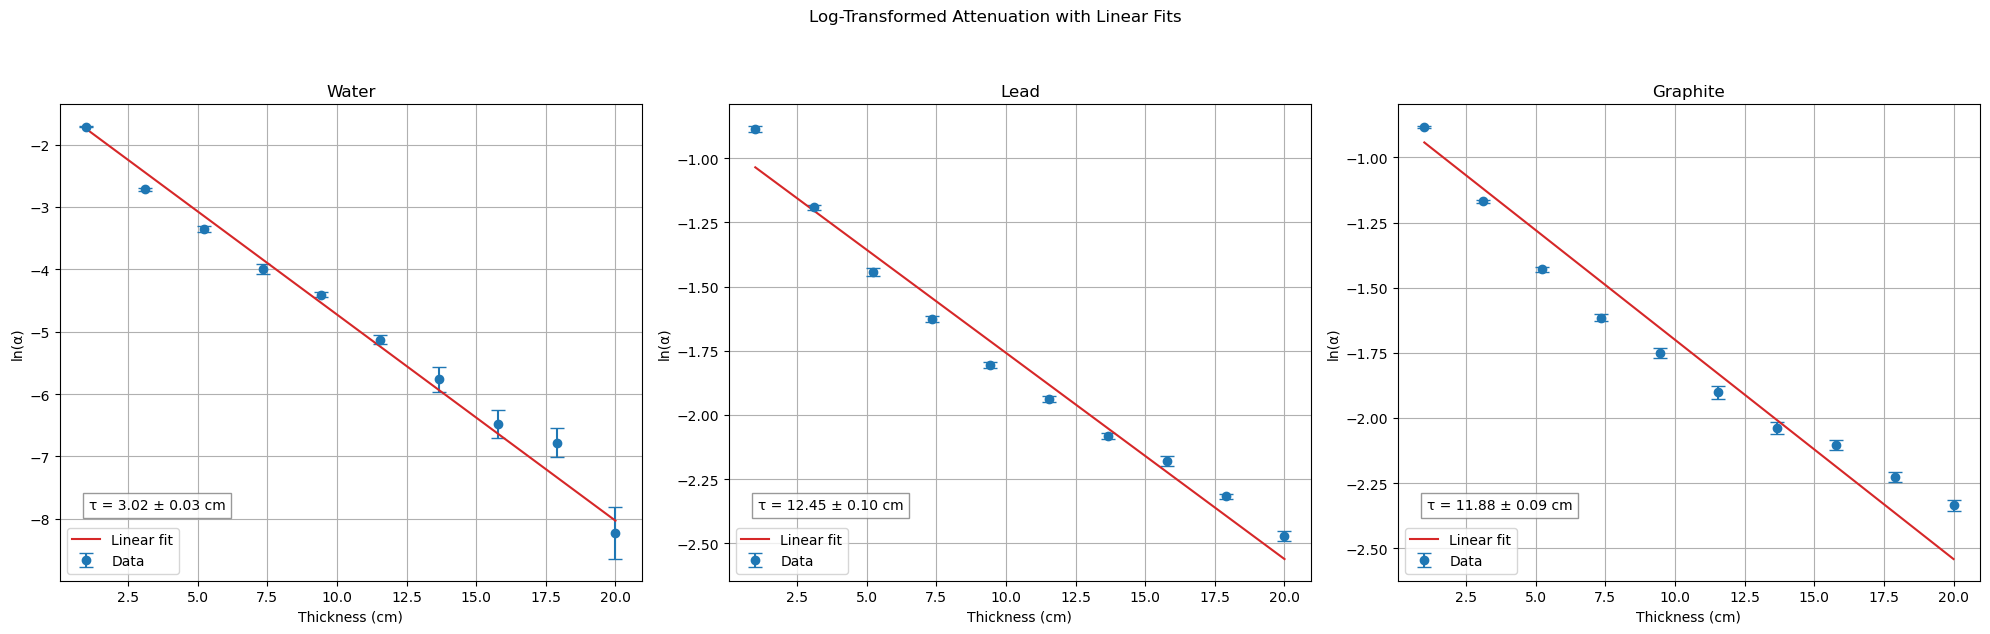

In [15]:
def fit_attenuation_simple(materials, thickness_values, n_neutrons=3000, n_repeats=5):
    """
    Linearise and plot attenuation data
    """
    results = {}
    
    # Preparing 3 plots within axes subplot
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Log-Transformed Attenuation with Linear Fits', y=1.05)
    
    for idx, (mat_name, material) in enumerate(materials.items()):
        # Calculate attenuation
        data = calculate_attenuation(material, thickness_values, n_neutrons, n_repeats)
        t = data['thicknesses']
        alpha = data['alpha']
        alpha_err = data['alpha_error']
        
        # Filter out zero transmissions which would disallow log calculation
        mask = alpha > 0
        if np.sum(mask) < 2:
            print(f"Warning: Not enough non-zero transmissions for {mat_name}")
            continue
            
        t_masked = t[mask]
        log_alpha = np.log(alpha[mask])
        log_err = alpha_err[mask]/alpha[mask]  # Error propagation: δ(lnα) = δα/α
        
        # Linear fit
        def linear_model(x, slope, intercept):
            return slope * x + intercept
        
        popt, pcov = curve_fit(linear_model, t_masked, log_alpha, 
                              sigma=log_err, absolute_sigma=True)
        slope, intercept = popt
        slope_err = np.sqrt(pcov[0, 0])
        
        # Calculate attenuation length using 1/slope
        tau = -1/slope
        tau_err = slope_err / slope**2
        
        # Store results
        results[mat_name] = {
            'tau': tau,
            'tau_error': tau_err,
            'intercept': intercept
        }
        
        # Plot
        ax = axes[idx]
        ax.errorbar(t_masked*100, log_alpha, yerr=log_err,
                   label='Data', color='tab:blue', marker='o', capsize=5, ls='none')
        ax.plot(t_masked*100, linear_model(t_masked, *popt), 
               color='tab:red', label='Linear fit')
        ax.set_xlabel('Thickness (cm)')
        ax.set_ylabel('ln(α)')
        ax.set_title(mat_name)
        ax.grid(True)
        
        # Add text box with results
        fit_text = f"τ = {tau*100:.2f} ± {tau_err*100:.2f} cm"
        ax.text(0.05, 0.15, fit_text, transform=ax.transAxes,
               bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
        ax.legend(loc='lower left')
    
    plt.tight_layout()
    plt.show()
    
    return results

thickness_values = np.linspace(0.01, 0.2, 10)  
results = fit_attenuation_simple(materials, thickness_values)

While performing a Chi-Squared analysis was beyond the scope of this project, we can see that the linearisation was visually successful for water, somewhat so for lead and graphite. This results in attenuation lengths of (2.98 $\pm$ 0.03) cm, (10.82 $\pm$ 0.07) and (13.59 $\pm$ 0.08) cm for water, lead and graphite respectively (subject to fluctuation in each attempt). 

## 5. Woodcock Method
The woodcock method is an alternative monte carlo technique that can simulate the movement of neutrons through various materials. While we have been looking at the material in one medium, this would allow the simulation of the neutron passing adjacent slabs of different materials without explicitly coding the properties of the boundaries [7]. To do so, we define the majorant cross section as

$$ \Sigma_m = \max (\Sigma_{t,1} , \Sigma_{t,2})$$
 
where $\Sigma_{t,1}$ and $\Sigma_{t,2}$ are the total cross sections of the materials. As the neutrons approach the cross section, there is an overestimation of the interaction probability. This 'virtual collision' is compared to where the real cross section lies. In the case that the real cross section is less than $\Sigma_M$, the program deems  that the neutron continues on its path. If it exceeds it, then an absorption or scattering is recorded. 

Uniformity is still important, but the step length is defined differently to previous. 

$$ \Delta s = -\frac{\ln(\varepsilon)}{\Sigma_m} $$

where $\varepsilon$ is a value between 0 and 1, and $\Delta s$ denotes the step length. This can be put together to evaluate the fraction of transmitted neutrons by counting those that escape the second slab. 

Computationally, we will use the majorant cross section to first overestimate the interaction probabilites. Then, by using the step length, we can determine whether the collisions are real or virtual. Real has been set to mean an absorption. To verify that the path of the neutrons are realistic, the final position is compared to the sum of two thicknesses (20cm) to ensure the neutrons have actually passed. 

As a method to ensure accuracy, the transmission fraction is calculated as the product of two of such exponential transmission values, and compared with the monte carlo result to validate it. In addition, the number of neutrons has been set to a higher number than before so that we can observe the stabilisation over attempts. 

The results of this will be shown in a table, which is most readable when the user's window size is maximised. 

In [16]:
from tabulate import tabulate

def compute_macroscopic_cross_section(material):
    """Compute macroscopic total cross-section (Σ_t) in cm^-1."""
    
    sigma_t = (material["sigma_abs"] + material["sigma_scat"]) * BARN  #in m^2
    atomic_density = (material["density"] * AVOGADRO) / material["molar_mass"]  # atoms per metre cubed
    sigma_t *= atomic_density * CM_PER_M  # Convert to cm^-1
    return sigma_t

def woodcock_method(sigma_t1, sigma_t2, thickness1, thickness2, n_neutrons):
    """
    Compute neutron transmission through two slabs using the Woodcock method as described above
    """
    sigma_m = max(sigma_t1, sigma_t2)  # Majorant cross-section
    transmitted = 0

    for _ in range(n_neutrons):
        x = 0.0  # Start at the left boundary of slab 1
        alive = True

        while alive:
            epsilon = np.random.random()
            delta_s = -np.log(epsilon) / sigma_m
            x_new = x + delta_s

            if x_new > thickness1 + thickness2:
                transmitted += 1
                alive = False
                break
            elif x_new < 0:
                alive = False
                break

            if x_new < thickness1:
                sigma_real = sigma_t1
            else:
                sigma_real = sigma_t2

            xi = np.random.random()
            if xi * sigma_m < sigma_real:
                alive = False
                break

            x = x_new

    return transmitted / n_neutrons

# Simulation parameters
thickness1 = 10.0  # cm
thickness2 = 10.0  # cm
n_neutrons = 10000

# Precompute cross-sections for all materials
material_names = list(materials.keys())
cross_sections = {name: compute_macroscopic_cross_section(materials[name]) for name in material_names}

# Compare all combinations
results = []
for mat1 in material_names:
    for mat2 in material_names:
        sigma_t1 = cross_sections[mat1]
        sigma_t2 = cross_sections[mat2]
        transmission = woodcock_method(sigma_t1, sigma_t2, thickness1, thickness2, n_neutrons)
        analytical = np.exp(-sigma_t1 * thickness1) * np.exp(-sigma_t2 * thickness2)
        results.append([mat1, mat2, f"{sigma_t1:.3f}", f"{sigma_t2:.3f}", 
                        f"{transmission:.6f}", f"{analytical:.6f}"])

# Display results in a table
headers = ["Slab 1", "Slab 2", "Σ_t1 (cm⁻¹)", "Σ_t2 (cm⁻¹)", "Transmission (Woodcock)", "Analytical (exp)"]
print(tabulate(results, headers=headers, tablefmt="grid", floatfmt=".6f"))

+----------+----------+---------------+---------------+---------------------------+--------------------+
| Slab 1   | Slab 2   |   Σ_t1 (cm⁻¹) |   Σ_t2 (cm⁻¹) |   Transmission (Woodcock) |   Analytical (exp) |
+==========+==========+===============+===============+===========================+====================+
| Water    | Water    |      0.035000 |      0.035000 |                  0.513000 |           0.500050 |
+----------+----------+---------------+---------------+---------------------------+--------------------+
| Water    | Lead     |      0.035000 |      0.004000 |                  0.672900 |           0.681091 |
+----------+----------+---------------+---------------+---------------------------+--------------------+
| Water    | Graphite |      0.035000 |      0.004000 |                  0.685900 |           0.679602 |
+----------+----------+---------------+---------------+---------------------------+--------------------+
| Lead     | Water    |      0.004000 |      0.035000 |

From the Woodcock method, we can see that water is highly absorbing, hence leading to almost no transmission when it is paired with other materials. Lead and Graphite resulted in more transparent transmissions, showing agreement with the analytical predictions. 

## 6. Conclusion
From the simulations, the attenuation lengths of neutron through water, lead and graphite were determined. These were values of (2.98 $\pm$ 0.03) cm, (10.82 $\pm$ 0.07) and (13.59 $\pm$ 0.08) cm for water, lead and graphite respectively. Past this, the behaviour of neutrons as it passed more than one slab was tested with the Woodcock method, showing that water is the most absorbant from the three materials. This concludes that water is the most effective neutron absorber.

## 7. References 

[1] Knuth, D. E. (1997). *The Art of Computer Programming, Volume 2: Seminumerical Algorithms* (3rd ed.). Addison-Wesley.

[2] Marsaglia, G., 1968. Random numbers fall mainly in the planes. Proceedings of the National Academy of Sciences, 61(1), pp.25–28. Available at: https://doi.org/10.1073/pnas.61.1.25

[3] Grimmett, G. and Stirzaker, D., 2001. Probability and random processes. 3rd ed. Oxford: Oxford University Press.
— See Chapter 7: The Law of Large Numbers.

[4] Devroye, L., 1986. Non-Uniform Random Variate Generation. New York: Springer-Verlag.

[5] Knoll, G.F., 2010. Radiation Detection and Measurement. 4th ed. Hoboken, NJ: John Wiley & Sons.

[6] Metropolis, N., Rosenbluth, A.W., Rosenbluth, M.N., Teller, A.H. and Teller, E., 1953. Equation of state calculations by fast computing machines. Journal of Chemical Physics, 21(6), pp.1087–1092. doi:10.1063/1.1699114.

[7] Woodcock, E.R., Murphy, T., Hemmings, P.J. and Longworth, T.C., 1965. Techniques used in the GEM code for Monte Carlo neutronics calculations in reactors and other systems of complex geometry. Proceedings of the Conference on Applications of Computing Methods to Reactor Problems, Argonne National Laboratory, USA.